**1**. **Setup & Installations**

In [9]:
!pip install torch torchvision numpy matplotlib


**2: Imports & Global Settings**

In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cpu


**3: CNN Model (Image Classifier)**

In [11]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.conv1(x))
        x = torch.relu(self.conv2(x))
        x = torch.max_pool2d(x, 2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        return self.fc2(x)


**4: Load Dataset (MNIST)**

In [12]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = datasets.MNIST(
    root="./data", train=False, download=True, transform=transform
)


100%|██████████| 9.91M/9.91M [00:00<00:00, 22.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 641kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 5.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.84MB/s]


**5: IID Data Partitioning**

In [13]:
def iid_partition(dataset, num_clients):
    indices = np.random.permutation(len(dataset))
    split_size = len(dataset) // num_clients

    client_data = {}
    for i in range(num_clients):
        client_indices = indices[i*split_size:(i+1)*split_size]
        client_data[i] = Subset(dataset, client_indices)

    return client_data


**6: Non-IID Data Partitioning (Label Skew)**

In [14]:
def noniid_partition(dataset, num_clients, shards_per_client=2):
    labels = np.array(dataset.targets)
    idxs = np.arange(len(labels))

    idxs_labels = np.vstack((idxs, labels))
    idxs_labels = idxs_labels[:, idxs_labels[1].argsort()]
    idxs = idxs_labels[0]

    num_shards = num_clients * shards_per_client
    shard_size = len(dataset) // num_shards

    shards = [idxs[i*shard_size:(i+1)*shard_size] for i in range(num_shards)]
    np.random.shuffle(shards)

    client_data = {}
    for i in range(num_clients):
        client_shards = shards[i*shards_per_client:(i+1)*shards_per_client]
        client_indices = np.concatenate(client_shards)
        client_data[i] = Subset(dataset, client_indices)

    return client_data


**7: Local Training at Client**

In [15]:
def local_train(model, dataloader, epochs=1):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn(model(x), y)
            loss.backward()
            optimizer.step()

    return model.state_dict()


**8: FedAvg Aggregation**

In [16]:
def fedavg(weights):
    avg_weights = {}
    for key in weights[0].keys():
        avg_weights[key] = torch.stack(
            [w[key].float() for w in weights], 0
        ).mean(0)
    return avg_weights


**9: Evaluation Function**

In [17]:
def evaluate(model, dataloader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for x, y in dataloader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total


**10: Federated Training Loop**

In [18]:
NUM_CLIENTS = 5
ROUNDS = 5
LOCAL_EPOCHS = 1

# Choose partition type
client_datasets = iid_partition(train_dataset, NUM_CLIENTS)
# client_datasets = noniid_partition(train_dataset, NUM_CLIENTS)

test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

global_model = CNN().to(DEVICE)
accuracy_list = []

for round in range(ROUNDS):
    print(f"\n--- Round {round+1} ---")
    client_weights = []

    for cid in range(NUM_CLIENTS):
        client_model = CNN().to(DEVICE)
        client_model.load_state_dict(global_model.state_dict())

        loader = DataLoader(client_datasets[cid], batch_size=32, shuffle=True)
        updated_weights = local_train(client_model, loader, LOCAL_EPOCHS)
        client_weights.append(updated_weights)

    global_weights = fedavg(client_weights)
    global_model.load_state_dict(global_weights)

    acc = evaluate(global_model, test_loader)
    accuracy_list.append(acc)
    print(f"Global Accuracy: {acc:.4f}")



--- Round 1 ---
Global Accuracy: 0.9630

--- Round 2 ---
Global Accuracy: 0.9847

--- Round 3 ---
Global Accuracy: 0.9877

--- Round 4 ---
Global Accuracy: 0.9892

--- Round 5 ---
Global Accuracy: 0.9900


**11: Plot Accuracy vs Rounds**

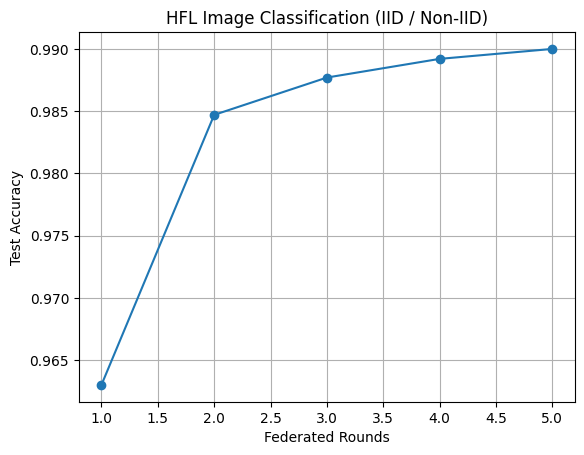

In [19]:
plt.plot(range(1, ROUNDS+1), accuracy_list, marker='o')
plt.xlabel("Federated Rounds")
plt.ylabel("Test Accuracy")
plt.title("HFL Image Classification (IID / Non-IID)")
plt.grid()
plt.show()
